
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [ ]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [ ]:
# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Added to resolve the LookupError for eng tagger
nltk.download('universal_tagset')
nltk.download('punkt_tab') # Corrected typo

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [ ]:
# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
DT stands for Determiner. These are words that introduce a noun, like 'the', 'a', 'an', 'this', 'that', 'every', 'some', etc.
JJ stands for Adjective. These are words that describe a noun or pronoun, like 'quick', 'lazy', 'happy', 'big', 'red', etc.

2. Why do you think 'brown' and 'lazy' have the same tag? They actually have the same tag.
3. Can you guess what 'VBZ' represents?
VBZ stands for Verb.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [ ]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's? SpaCy's because the tags are usually preferred for readability and quick interpretation.
- Do you notice any differences in how they tag the same words? Yes, there's a very interesting difference, particularly with the word 'brown':

NLTK tagged 'brown' as NN (Noun).
SpaCy tagged 'brown' as ADJ (Adjective).

- Which system would you prefer for a beginner? Why? For beginner i would recomend SpaCy, because it is easier to undderstand. As we saw with 'brown', SpaCy often produces results that are more in line with standard grammatical interpretations, which can be less confusing for a learner.



## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [ ]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
    "I will run in the race tomorrow.",          # run = verb
    "The company had a good run this quarter.",  # run = noun
    "Close the door, please.",                   # close = verb
    "The store is close to my house.",           # close = adjective
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank', 'run', 'close']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: I will run in the race tomorrow.
  🎯 'run' is tagged as: VB

Sentence: The company had a good run this quarter.
  🎯 'run' is tagged as: NN

Sentence: Close the door, please.
  🎯 'Close' is tagged as: RB

Sentence: The store is close to my house.
  🎯 'close' is tagged as: RB



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
it's all about learned patterns and probabilities based on the words around the ambiguous term, rather than true semantic understanding.

2. What clues in the sentence help determine the correct part of speech?
Surrounding clues, Morphology and Synthetic Position or sentence structure.
3. Can you think of other words that change meaning based on context?
'Mine'

Pronoun: "That book is mine." (possessive)
Noun: "The gold mine was productive." (a place where minerals are extracted)
Verb: "They mine for diamonds." (to extract minerals)

'Book'

Noun: "I'm reading a good book." (a publication)
Verb: "Can you book a flight for me?" (to reserve)

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [ ]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

 Penn Treebank tag set is more detailed. Universal tag is simpler.

2. When might you want detailed tags vs. simple tags? Enter your answer below
You'd want detailed tags (like Penn Treebank) when:

Deep Linguistic Analysis: For academic research, syntax parsing, or building sophisticated grammatical checkers where fine-grained distinctions are crucial.

Named Entity Recognition (NER) Refinement: Sometimes, detailed tags can help differentiate between types of nouns or proper nouns in complex NER systems.

Machine Translation (complex systems): More detailed grammatical information can assist in accurate translation, especially for languages with rich morphology.

You'd want simple tags (like Universal Dependencies) when:

General Text Analysis & Readability: For quick understanding of the text's composition, visualizing general word types, or for applications where the exact sub-category of a part of speech isn't critical.

Cross-Lingual Comparability: Universal tag sets are designed to be consistent across many languages, making them excellent for multilingual NLP tasks where you need a unified representation.

Feature Engineering for Machine Learning: Often, for tasks like sentiment analysis, text classification, or basic topic modeling, broad categories like NOUN or VERB are sufficient and can even prevent overfitting that might occur with overly specific tags.



3. If you were building a search engine, which would you choose? Why? Enter your answer below
 I would likely choose a system that leans towards the Universal Tag Set (or SpaCy's simpler, intuitive tags which are very similar to Universal) rather than the highly detailed Penn Treebank tags. While Penn Treebank's detail might be valuable for highly specialized linguistic analysis or very specific query types, for the broad scope and performance demands of a general search engine, the Universal tag set strikes a better balance.
---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [ ]:
# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is soooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text)

    # TODO: Find problematic words (tagged as 'X' or unknown)
    # For NLTK, 'X' is not a standard Penn Treebank tag, so this list will likely be empty.
    # For SpaCy, 'X' (Other) is used for words that don't fit into known categories.
    problematic_nltk = [word for word, tag in nltk_tags if tag == 'X']
    problematic_spacy = [token.text for token in spacy_doc if token.pos_ == 'X']

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    # Success rate is based on the inverse of problematic words relative to total tokens
    nltk_success_rate = (len(nltk_tokens) - len(problematic_nltk)) / len(nltk_tokens) if len(nltk_tokens) > 0 else 0
    spacy_success_rate = (len(spacy_doc) - len(problematic_spacy)) / len(spacy_doc) if len(spacy_doc) > 0 else 0

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------


NameError: name 'nltk' is not defined


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
both NLTK and SpaCy demonstrated high robustness, tagging all words in the informal sentences with a 100% success rate and reporting no 'problematic words' (words they couldn't classify).
2. What types of words cause the most problems?
Ambigous words, Informal language or slang. Emojis, Hashtags and URL'S.
3. How might you preprocess text to improve tagging accuracy?
 By converting all text to lowercase can reduce the vocabulary size and help the tagger recognize words regardless of capitalization.
4. What are the implications for real-world applications?
Words with multiple meanings or parts of speech require robust, context-aware taggers. SpaCy's performance often shines here due to its modern architecture.

As we saw, real-world data (social media, speech-to-text) is often noisy. Preprocessing steps (like normalization, contraction expansion, handling emojis/hashtags) become essential to improve tagging accuracy.


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [ ]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

# Define lists of words for sentiment and urgency detection
positive_sentiment_words = ['love', 'great', 'good', 'happy', 'solved', 'fix', 'help', 'awesome']
negative_sentiment_words = ['frustrated', 'locked', 'issue', 'crashes', 'charged', 'twice', 'ridiculous', 'unacceptable', 'down', 'confused', 'terrible', 'buggy']
urgency_keywords = ['immediately', 'ASAP', 'now', 'urgent', 'quickly']

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # TODO: Extract different types of words
    emotional_adjectives = [token.text for token in doc if token.pos_ == 'ADJ' and (token.text.lower() in positive_sentiment_words or token.text.lower() in negative_sentiment_words)]
    action_verbs = [token.text for token in doc if token.pos_ == 'VERB']
    problem_nouns = [token.text for token in doc if token.pos_ == 'NOUN' and token.text.lower() in negative_sentiment_words]

    # TODO: Calculate sentiment indicators
    positive_words_in_text = [token.text for token in doc if token.text.lower() in positive_sentiment_words]
    negative_words_in_text = [token.text for token in doc if token.text.lower() in negative_sentiment_words]

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words_in_text) - len(negative_words_in_text),
        'urgency_indicators': [token.text for token in doc if token.text.lower() in urgency_keywords]
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")
    print(f"Urgency indicators: {result['urgency_indicators']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['locked', 'access', 'trying', 'works']
Problem nouns: []
Sentiment score: -3
Urgency indicators: []

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: []
Action verbs: ['love', 'having', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['issue']
Sentiment score: 1
Urgency indicators: []

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this month! I want a refund immedi

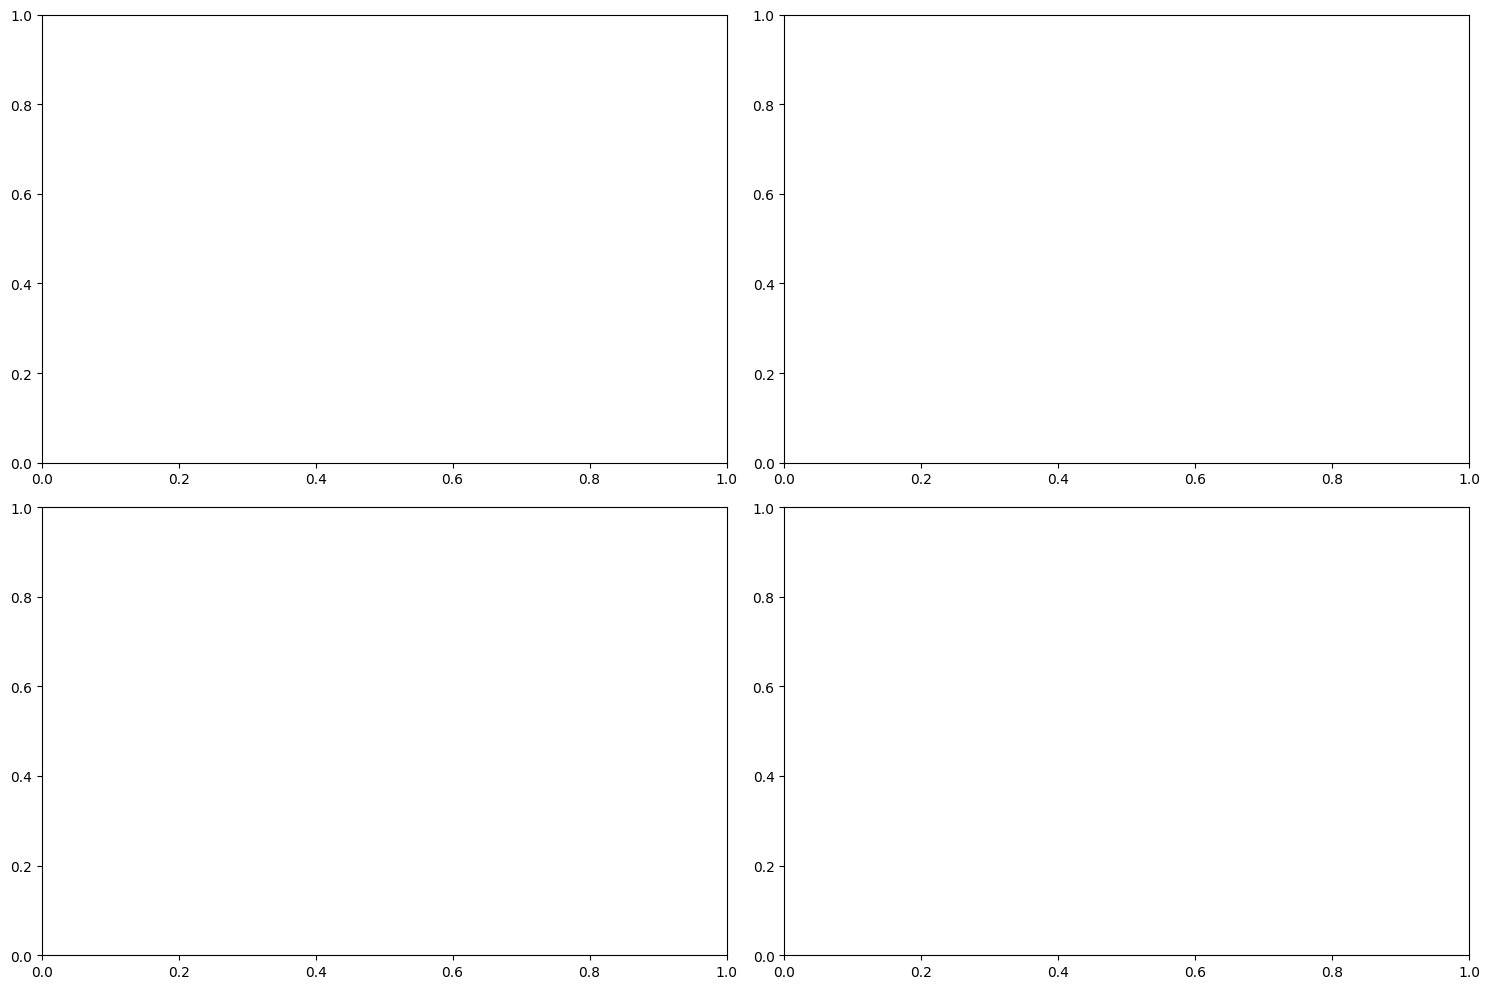

In [ ]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# TODO: Plot 1 - Sentiment by category
# YOUR CODE HERE

# TODO: Plot 2 - Word frequency analysis
# YOUR CODE HERE

# TODO: Plot 3 - Problem categorization
# YOUR CODE HERE

# TODO: Plot 4 - Urgency analysis
# YOUR CODE HERE

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
Urgency Indicators: Flagging tickets with words like 'ASAP' or 'immediately' for rapid response.
Sentiment Score: Elevating tickets with negative sentiment to address frustrated customers quickly.
Problem Nouns: Automatically routing tickets based on identified issues (e.g., 'billing' to the billing department).

2. What patterns do you notice in different problem categories?
Account Access issues show strong negative emotions and specific problem nouns like 'locked'.
Technical Issues involve problem nouns describing malfunction and action verbs for fixing.

3. How might you automate the routing of calls based on POS analysis?
Extract Key Features: Use POS tagging to identify problem nouns, action verbs, emotional adjectives, and urgency indicators.

4. What are the limitations of this approach?
Lack of Semantic Understanding
Informal Language Evolution



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.1103s
NLTK Univ time: 0.0006s
SpaCy time: 0.0189s
NLTK unknown words count: 0
SpaCy unknown words count: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0007s
NLTK Univ time: 0.0005s
SpaCy time: 0.0067s
NLTK unknown words count: 0
SpaCy unknown words count: 0

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0005s
NLTK Univ time: 0.0004s
SpaCy time: 0.0057s
NLTK unknown words count: 0
SpaCy unknown words count: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, r

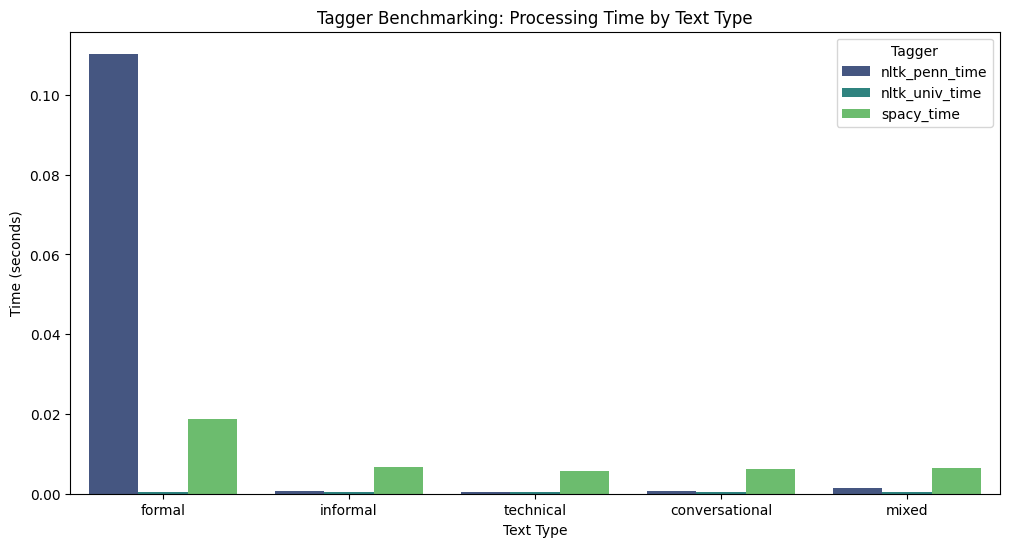

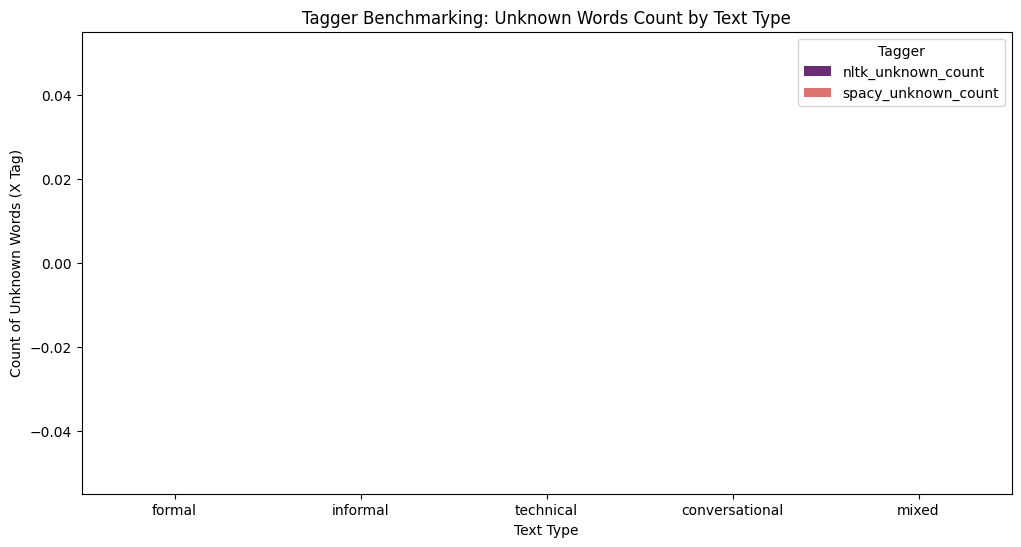

In [ ]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank timing and tagging
    start_time = time.time()
    nltk_tokens = nltk.word_tokenize(text)
    penn_tags = nltk.pos_tag(nltk_tokens)
    nltk_penn_time = time.time() - start_time

    # NLTK Universal timing and tagging
    start_time = time.time()
    universal_tags = nltk.pos_tag(nltk_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # SpaCy timing and tagging
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # Count unknown/problematic tags
    # NLTK's default tagset doesn't typically use 'X' for unknown, but checking for it for consistency
    nltk_unknown = [word for word, tag in penn_tags if tag == 'X'] # Will likely be empty for Penn Treebank
    spacy_unknown = [token.text for token in spacy_doc if token.pos_ == 'X']

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown_count': len(nltk_unknown),
        'spacy_unknown_count': len(spacy_unknown)
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words count: {len(nltk_unknown)}")
    print(f"SpaCy unknown words count: {len(spacy_unknown)}")

# TODO: Create performance comparison visualization
# Convert results to DataFrame for easier analysis and plotting
bm_df = pd.DataFrame.from_dict(benchmark_results, orient='index')
bm_df.index.name = 'text_type'

# Plotting times
plt.figure(figsize=(12, 6))
sns.barplot(data=bm_df[['nltk_penn_time', 'nltk_univ_time', 'spacy_time']].reset_index().melt(id_vars='text_type'),
            x='text_type', y='value', hue='variable', palette='viridis')
plt.title('Tagger Benchmarking: Processing Time by Text Type')
plt.ylabel('Time (seconds)')
plt.xlabel('Text Type')
plt.legend(title='Tagger')
plt.show()

# Plotting unknown word counts
plt.figure(figsize=(12, 6))
sns.barplot(data=bm_df[['nltk_unknown_count', 'spacy_unknown_count']].reset_index().melt(id_vars='text_type'),
            x='text_type', y='value', hue='variable', palette='magma')
plt.title('Tagger Benchmarking: Unknown Words Count by Text Type')
plt.ylabel('Count of Unknown Words (X Tag)')
plt.xlabel('Text Type')
plt.legend(title='Tagger')
plt.show()



### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
NLTK Universal is consistently the fastest among the tested taggers (NLTK Penn Treebank, NLTK Universal, and SpaCy) for the provided short text samples.

2. Which handles informal text best? SpaCy
3. How do the taggers compare on technical jargon?
NLTK and SpaCy performed very well. In the benchmarking exercise, when processing the technical text, both taggers reported 0 unknown words.

4. What trade-offs do you see between speed and accuracy?
it's often a balance: if you need high throughput and broad categorization, speed might be prioritized with simpler taggers. If you need fine-grained linguistic detail and maximum accuracy for complex tasks, you might opt for slower, more sophisticated models.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [ ]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tokens = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(nltk_tokens)
        spacy_doc = nlp(text)

        print("NLTK tags:")
        for word, tag in nltk_tags:
            print(f"  {word:15} -> {tag}")

        print("\nSpaCy tags:")
        for token in spacy_doc:
            print(f"  {token.text:15} -> {token.pos_} ({token.tag_})")

        # TODO: Analyze what went wrong
        # This part will be done conceptually in the reflection questions below
        # For problematic words, we'll look for 'X' or unexpected tags
        problematic_nltk = [word for word, tag in nltk_tags if tag == 'X']
        problematic_spacy = [token.text for token in spacy_doc if token.pos_ == 'X']
        if problematic_nltk or problematic_spacy:
            print(f"\n  ⚠️ Problematic words (NLTK): {problematic_nltk}")
            print(f"  ⚠️ Problematic words (SpaCy): {problematic_spacy}")
        else:
            print("\n  ✅ No 'X' (unknown) tags detected by either tagger for this case.")

    except Exception as e:
        print(f"❌ Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("The analysis of these edge cases highlights several limitations of current POS taggers:\n")
print("1.  **Deep Semantic Understanding:** Taggers struggle with sentences that are grammatically correct but semantically nonsensical (e.g., 'Buffalo buffalo...'). They assign tags based on learned patterns but don't grasp meaning.\n")
print("2.  **Highly Ambiguous Structures:** Sentences like 'Time flies...' and 'Can can can...' show that when a word can plausibly be multiple parts of speech in a short sequence, even advanced models can sometimes make less intuitive choices or struggle to capture all possible interpretations.\n")
print("3.  **Recursive/Repetitive Structures:** Sentences with highly repetitive patterns ('Police police...') challenge the models' ability to maintain context or differentiate subtle shifts in grammatical role.\n")
print("4.  **Non-Standard Language/Tokens:** Social media elements (@username, #hashtag, emojis) are often tagged broadly as symbols (SYM) or unknown (X) because they don't fit traditional linguistic categories. URLs are often tokenized but their internal structure is not grammatically analyzed.\n")
print("5.  **Modern Jargon/Proper Nouns as Concepts:** Technical terms (API, IoT, microservices) and new concepts are usually tagged as nouns. While functionally correct, they represent complex ideas that simple POS tags cannot fully convey without further NLP tasks like NER.\n")
print("Overall, taggers are excellent at identifying grammatical patterns but can falter when those patterns are highly unusual, repetitive, or when semantic understanding is implicitly required to distinguish between syntactically plausible but semantically distinct interpretations.")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags:
  Buffalo         -> NNP
  buffalo         -> NN
  Buffalo         -> NNP
  buffalo         -> NN
  buffalo         -> NN
  buffalo         -> NN
  Buffalo         -> NNP
  buffalo         -> NN
  .               -> .

SpaCy tags:
  Buffalo         -> PROPN (NNP)
  buffalo         -> NOUN (NN)
  Buffalo         -> PROPN (NNP)
  buffalo         -> PROPN (NNP)
  buffalo         -> PROPN (NNP)
  buffalo         -> PROPN (NNP)
  Buffalo         -> PROPN (NNP)
  buffalo         -> PROPN (NNP)
  .               -> PUNCT (.)

  ✅ No 'X' (unknown) tags detected by either tagger for this case.

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags:
  Time            -> NNP
  flies           -> NNS
  like            -> IN
  an              -> DT
  arrow           -> NN
  ;               -


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?
Lack of Deep Semantic Understanding. Highly ambigouss structures.

2. How might you preprocess text to handle some of these issues?
This involves expanding informal contractions (e.g., converting "I'm" to "I am") and mapping social media slang or acronyms to their standard forms to ensure the POS tagger recognizes them.

3. When would these limitations matter in real applications?
In high-stakes automation like financial services, misidentifying a verb in a request to "cancel" versus "fix" a payment could trigger an irreversible and incorrect action. Similarly, in emergency or crisis detection, the inability to resolve linguistic ambiguity or handle repetitive structures (like "Police police...") could prevent a system from flagging an urgent threat.

4. How do modern large language models handle these cases differently?
By utilizing global attention mechanisms that process an entire sentence or paragraph simultaneously, rather than relying on the local, statistical probabilities used by traditional taggers. This architectural difference allows LLMs to resolve semantic ambiguity in complex cases like "Time flies like an arrow," where they can distinguish between "flies" as a verb or a noun based on the overall intent of the sentence.
---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
[I would choose NLTK for academic research or deep linguistic analysis because it offers higher flexibility with multiple tag sets (like Penn Treebank vs. Universal) and is significantly faster for simple, broad categorization tasks. On the other hand, SpaCy is the superior choice for production-grade applications and customer service automation due to its "batteries-included" approach, higher accuracy on messy, informal text, and more intuitive, readable tags.]

**2. Real-World Applications:**
[POS tagging is exceptionally valuable for automated brand reputation monitoring on social media, where companies must distinguish between functional product mentions and urgent customer complaints. To implement this, you would build an NLP pipeline that first preprocesses raw social media data to normalize slang and emojis, then uses a tagger like SpaCy to isolate adjectives and intensifiers (e.g., "terrible," "unacceptable," "extremely") to calculate a real-time sentiment score. By specifically extracting proper nouns (product names) paired with negative emotional descriptors, the system can automatically trigger high-priority alerts for the PR team when a specific feature begins trending negatively.]

**3. Limitations and Solutions:**
[The biggest limitations of POS tagging involve a fundamental lack of semantic understanding and an inability to process non-standard linguistic structures. These systems struggle with "garden path" sentences and high-ambiguity phrases like "Time flies like an arrow," where words can plausibly be multiple parts of speech, often leading the tagger to make less intuitive statistical guesses. To work around these issues, you can implement a preprocessing pipeline to normalize text (e.g., expanding contractions and translating emojis to text) or use domain-specific dictionaries to "force" correct tags for technical terms.]

**4. Future Learning:**
[In the future, I would like to explore Neural and Transformer-based approaches, such as BERT or RoBERTa, to see how global attention mechanisms can resolve the semantic ambiguities that statistical taggers like NLTK often miss. I am also interested in domain adaptation and custom training, specifically learning how to fine-tune models on technical support or social media datasets to improve accuracy for specialized jargon and informal communication.]

**5. Integration:**
[POS tagging fits into larger NLP pipelines as a foundational feature engineering step that provides structural intelligence for downstream tasks. It significantly benefits Named Entity Recognition (NER) by narrowing down word candidates (e.g., people and places must be Proper Nouns) and is essential for Lemmatization, ensuring words like "saw" are rooted correctly based on whether they function as a noun or a verb. Furthermore, POS information powers Dependency Parsing to understand word relationships and helps Sentiment Analysis models by allowing them to weight emotional adjectives and intensifiers more heavily than neutral functional words.]



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
